In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv(r"C:\Users\Thai Binh\Documents\HocHanh\Python\project\Depression Prediction\Student Depression Dataset.csv")
df.head()
df.info()
print(df["Depression"].value_counts())
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [34]:
# Drop unnecessary identifier
df = df.drop(columns=["id"])

# Clean Financial Stress
df["Financial Stress"] = pd.to_numeric(df["Financial Stress"], errors="coerce")
df = df.dropna(subset=["Financial Stress"])

# Clean Sleep Duraion
df["Sleep Duration"] = df["Sleep Duration"].str.replace("'", "", regex=False).str.strip()

sleep_map = {
    "Less than 5 hours": 4,
    "5-6 hours": 5.5,
    "7-8 hours": 7.5,
    "More than 8 hours": 9,
    "Others": None
}

df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)
df['Sleep Duration'] = df['Sleep Duration'].fillna(df['Sleep Duration'].median())

# Binary encoding
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({"Yes": 1 , "No": 0})
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({"Yes": 1, "No": 0})
df['Gender'] = df['Gender'].map({"Male":1, "Female": 0})

# Ordianl encoding
diet_map = {
    "Unhealthy": 0,
    "Moderate": 1,
    "Healthy": 2,
    "Others": 1
}

# One-hot encoding
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)
df = pd.get_dummies(df, columns=["Profession"], drop_first=True)

# Drop less use collumns
df = df.drop(columns=["Degree", "City"])


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27898 entries, 0 to 27900
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27898 non-null  int64  
 1   Age                                    27898 non-null  float64
 2   Academic Pressure                      27898 non-null  float64
 3   Work Pressure                          27898 non-null  float64
 4   CGPA                                   27898 non-null  float64
 5   Study Satisfaction                     27898 non-null  float64
 6   Job Satisfaction                       27898 non-null  float64
 7   Sleep Duration                         27898 non-null  float64
 8   Dietary Habits                         27898 non-null  int64  
 9   Have you ever had suicidal thoughts ?  27898 non-null  int64  
 10  Work/Study Hours                       27898 non-null  float64
 11  Financi

In [36]:
df["Depression_label"] = df["Depression"].map({0:"Not Depressed", 1: "Depressed"})

<function matplotlib.pyplot.show(close=None, block=None)>

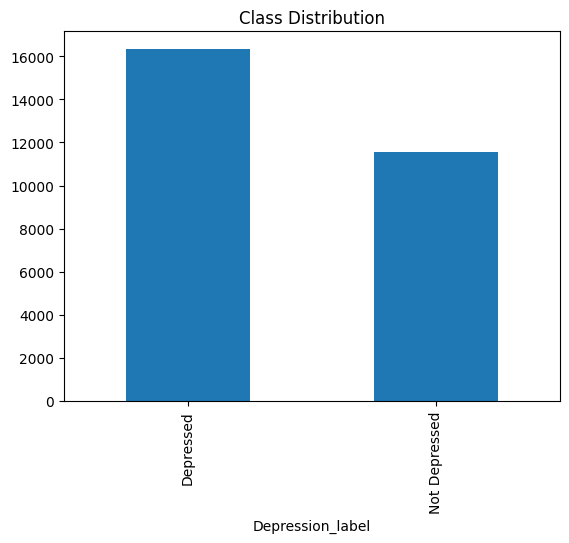

In [37]:
df["Depression_label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show

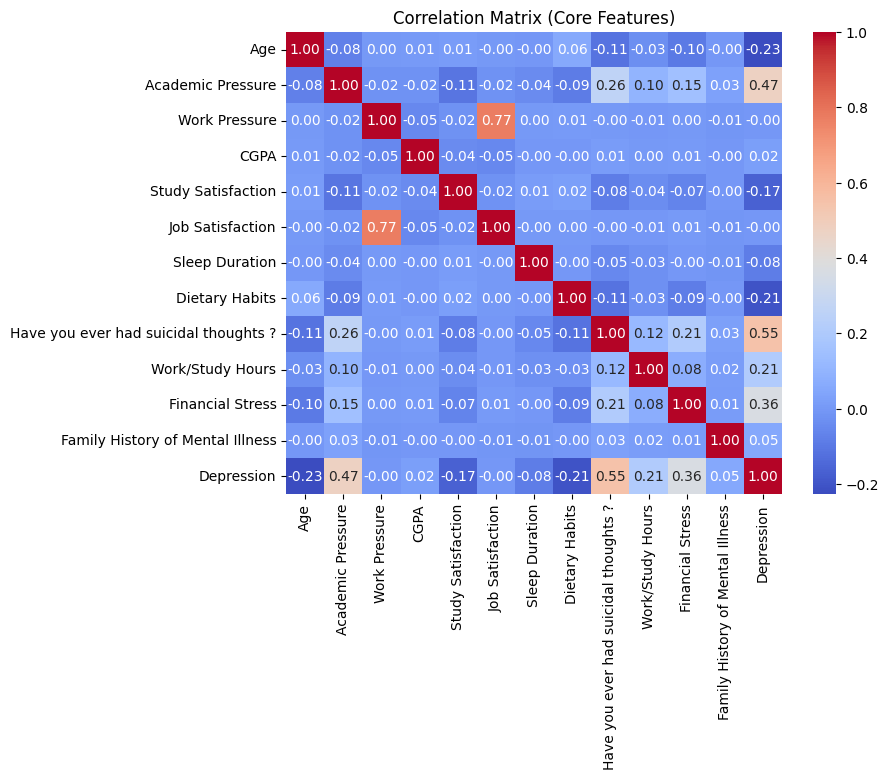

In [38]:
core_features = [
    "Age",
    "Academic Pressure",
    "Work Pressure",
    "CGPA",
    "Study Satisfaction",
    "Job Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Have you ever had suicidal thoughts ?",
    "Work/Study Hours",
    "Financial Stress",
    "Family History of Mental Illness",
    "Depression"
]
plt.figure(figsize=(8,6))
sns.heatmap(df[core_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Core Features)")
plt.show()

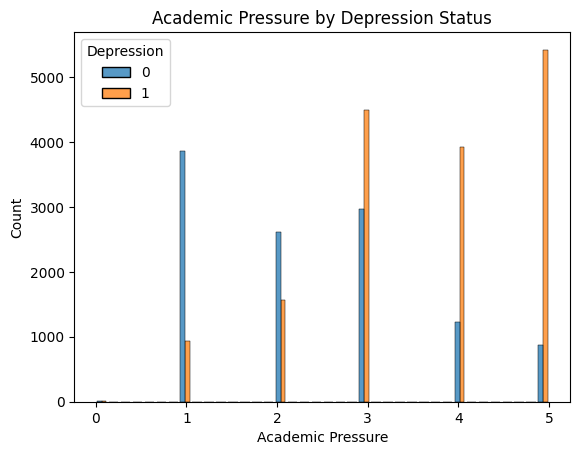

In [39]:
sns.histplot(data=df, x="Academic Pressure", hue="Depression", multiple="dodge", shrink=0.8)
plt.title("Academic Pressure by Depression Status")
plt.show()

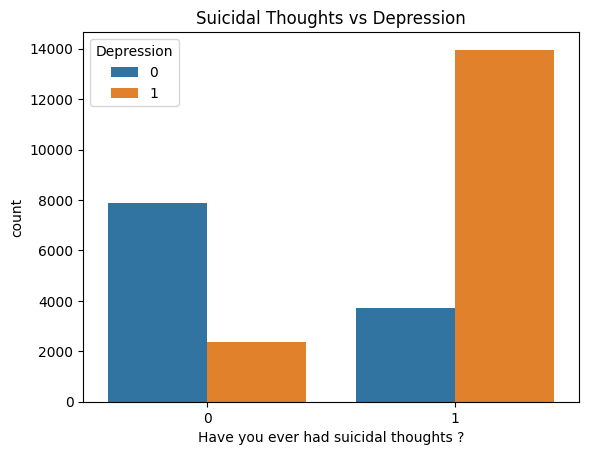

In [40]:
sns.countplot(x="Have you ever had suicidal thoughts ?", hue="Depression",data=df)
plt.title("Suicidal Thoughts vs Depression")
plt.show()

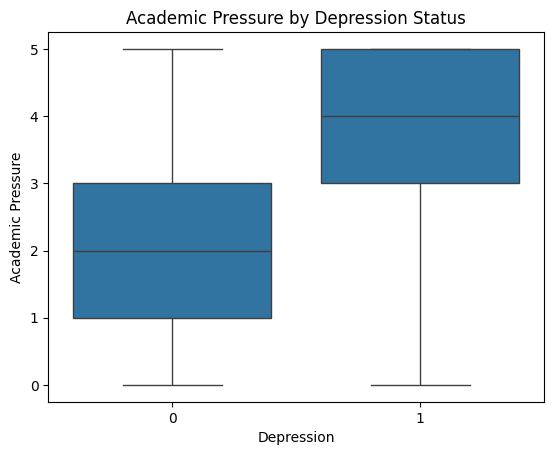

In [41]:
sns.boxplot(x="Depression", y="Academic Pressure", data=df)
plt.title("Academic Pressure by Depression Status")
plt.show()

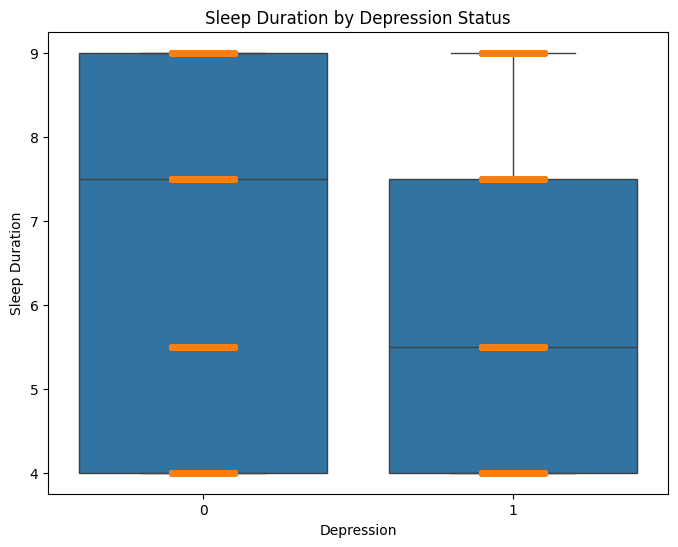

In [42]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Depression", y="Sleep Duration", data=df)
sns.stripplot(x="Depression", y="Sleep Duration", data=df)

plt.title("Sleep Duration by Depression Status")
plt.xlabel("Depression")
plt.ylabel("Sleep Duration")
plt.show()

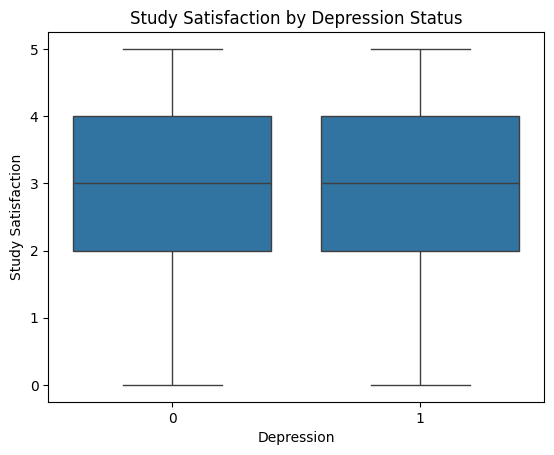

In [43]:
sns.boxplot(x="Depression", y="Study Satisfaction", data=df)
plt.title("Study Satisfaction by Depression Status")
plt.show()

In [44]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [45]:
X = df.drop(columns=["Depression", "Depression_label"])
y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression with suicidal thoughts

Accuracy: 0.8455197132616488
Precision: 0.8573551263001485
Recall: 0.8830731558004286
AUC: 0.9182872760674121


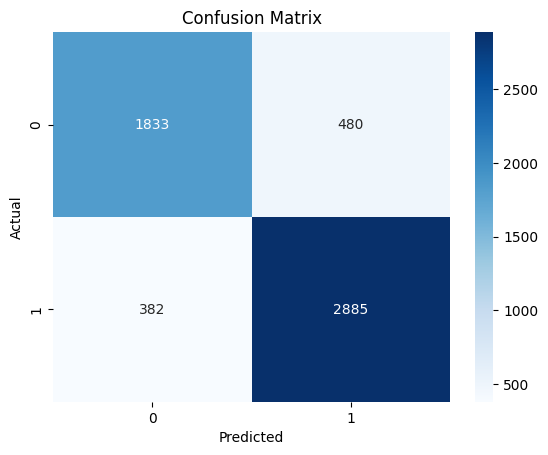


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.88      0.87      3267

    accuracy                           0.85      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.85      0.84      5580



In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_probs_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_probs_lr))

conf_matrix = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression without suicidal thoughts

Accuracy: 0.7994623655913978
Precision: 0.8107638888888888
Recall: 0.8576675849403123
AUC: 0.8694743951985628


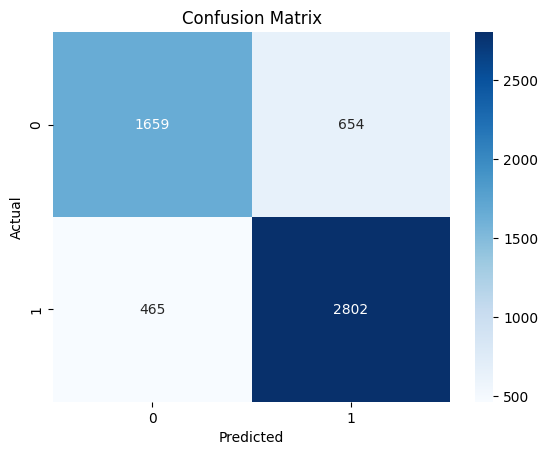


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75      2313
           1       0.81      0.86      0.83      3267

    accuracy                           0.80      5580
   macro avg       0.80      0.79      0.79      5580
weighted avg       0.80      0.80      0.80      5580



In [47]:
df_no_suicide = df.drop(columns=["Have you ever had suicidal thoughts ?"])

X_no_suicide = df_no_suicide.drop(columns=["Depression", "Depression_label"
                                           ])
y_no_suicide = df_no_suicide["Depression"]

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_suicide,
    y_no_suicide,
    test_size=0.2,
    random_state=42,
    stratify=y_no_suicide
)

scaler_ns = StandardScaler()
X_train_ns_scaled = scaler_ns.fit_transform(X_train_ns)
X_test_ns_scaled = scaler_ns.transform(X_test_ns)

lr_no_suicide = LogisticRegression(max_iter=1000)
lr_no_suicide.fit(X_train_ns_scaled, y_train_ns)

y_pred_ns = lr_no_suicide.predict(X_test_ns_scaled)
y_probs_ns = lr_no_suicide.predict_proba(X_test_ns_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test_ns, y_pred_ns))
print("Precision:", precision_score(y_test_ns, y_pred_ns))
print("Recall:", recall_score(y_test_ns, y_pred_ns))
print("AUC:", roc_auc_score(y_test_ns, y_probs_ns))
conf_matrix = confusion_matrix(y_test_ns, y_pred_ns)
sns.heatmap(conf_matrix, annot=True,fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", classification_report(y_test_ns, y_pred_ns))

Random Forest

Accuracy: 0.8369175627240143
Precision: 0.8485655131617864
Recall: 0.8781756963575146
AUC: 0.9110664082955087


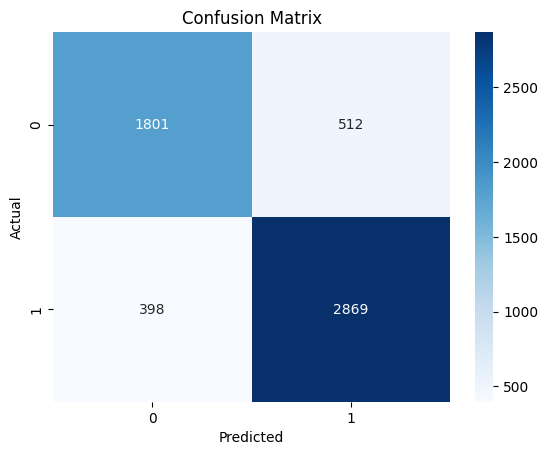


Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.83      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



In [48]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:,1]


print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_probs_rf))

conf_matrix = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix, annot=True,fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

XGBoost with suicidal thoughts

Accuracy:, 0.8465949820788531
Precision: 0.8571851851851852
Recall: 0.8855218855218855
AUC: 0.9180916847072568


c:\Users\Thai Binh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:27:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


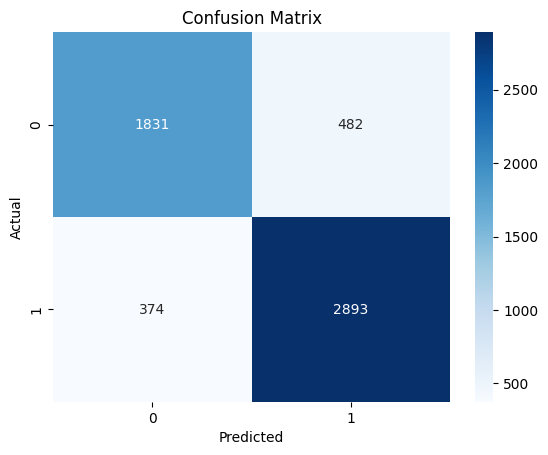


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.89      0.87      3267

    accuracy                           0.85      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.85      0.85      0.85      5580



In [49]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimator= 150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metrics="logloss"
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_probs_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Accuracy:,", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_probs_xgb))

conf_matrix = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(conf_matrix, annot=True,fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost without suicidal thoughts

Accuracy: 0.7982078853046595
Precision: 0.8078803566292782
Recall: 0.8598102234465871
AUC: 0.8703889634597491


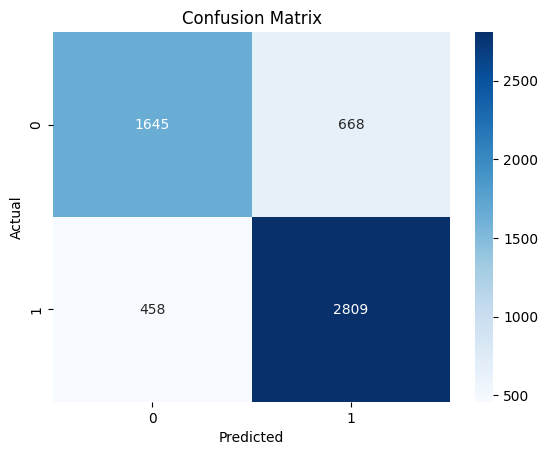


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.71      0.75      2313
           1       0.81      0.86      0.83      3267

    accuracy                           0.80      5580
   macro avg       0.80      0.79      0.79      5580
weighted avg       0.80      0.80      0.80      5580



In [50]:
xgb_model_ns = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model_ns.fit(X_train_ns, y_train_ns)

y_pred_xgb_ns = xgb_model_ns.predict(X_test_ns)
y_probs_xgb_ns = xgb_model_ns.predict_proba(X_test_ns)[:,1]

print("Accuracy:", accuracy_score(y_test_ns, y_pred_xgb_ns))    
print("Precision:", precision_score(y_test_ns, y_pred_xgb_ns))
print("Recall:", recall_score(y_test_ns, y_pred_xgb_ns))
print("AUC:", roc_auc_score(y_test_ns, y_probs_xgb_ns))

conf_matrix = confusion_matrix(y_test_ns, y_pred_xgb_ns)
sns.heatmap(conf_matrix, annot=True,fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print("\nClassification Report:\n", classification_report(y_test_ns, y_pred_xgb_ns))

Model Evaluation and Comparison

In [51]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (no suicidal-thoughts)",
        "Random Forest",
        "XGBoost",
        "XGBoost (no suicidal-thoughts)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test_ns, y_pred_ns),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test_ns, y_pred_xgb_ns)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test_ns, y_pred_ns),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test_ns, y_pred_xgb_ns)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test_ns, y_pred_ns),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test_ns, y_pred_xgb_ns)
    ],
    "AUC": [
        roc_auc_score(y_test, y_probs_lr),
        roc_auc_score(y_test_ns, y_probs_ns),
        roc_auc_score(y_test, y_probs_rf),
        roc_auc_score(y_test, y_probs_xgb),
        roc_auc_score(y_test_ns, y_probs_xgb_ns)
    ]
})

print(results.round(3))

                                        Model  Accuracy  Precision  Recall  \
0                         Logistic Regression     0.846      0.857   0.883   
1  Logistic Regression (no suicidal-thoughts)     0.799      0.811   0.858   
2                               Random Forest     0.837      0.849   0.878   
3                                     XGBoost     0.847      0.857   0.886   
4              XGBoost (no suicidal-thoughts)     0.798      0.808   0.860   

     AUC  
0  0.918  
1  0.869  
2  0.911  
3  0.918  
4  0.870  


In [52]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

cv_lr = cross_val_score(
    pipeline_lr,
    X, y,
    cv=5,
    scoring="roc_auc"
)

# Random Forest CV
cv_rf = cross_val_score(
    RandomForestClassifier(n_estimators=500, random_state=42),
    X, y,
    cv=5,
    scoring="roc_auc"
)

# XGBoost CV
cv_xgb = cross_val_score(
    XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ),
    X, y,
    cv=5,
    scoring="roc_auc"
)

# Combine CV results into one table
cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "CV Mean AUC": [cv_lr.mean(), cv_rf.mean(), cv_xgb.mean()]
})

In [53]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results_thresh = []

for t in thresholds:
    y_pred_t = (y_probs_xgb >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)

    results_thresh.append([t, precision, recall])

df_thresh = pd.DataFrame(results_thresh, columns=["Threshold", "Precision", "Recall"])

# Adding F1-score
df_thresh["F1"] = 2 * (df_thresh["Precision"] * df_thresh["Recall"]) / \
                 (df_thresh["Precision"] + df_thresh["Recall"])

print(df_thresh.round(3))

# Find best threshold
best_row = df_thresh.loc[df_thresh["F1"].idxmax()]
print("\nBest threshold based on F1:")
print(best_row)

   Threshold  Precision  Recall     F1
0        0.1      0.698   0.989  0.818
1        0.2      0.754   0.971  0.849
2        0.3      0.792   0.947  0.863
3        0.4      0.828   0.916  0.870
4        0.5      0.857   0.886  0.871

Best threshold based on F1:
Threshold    0.500000
Precision    0.857185
Recall       0.885522
F1           0.871123
Name: 4, dtype: float64


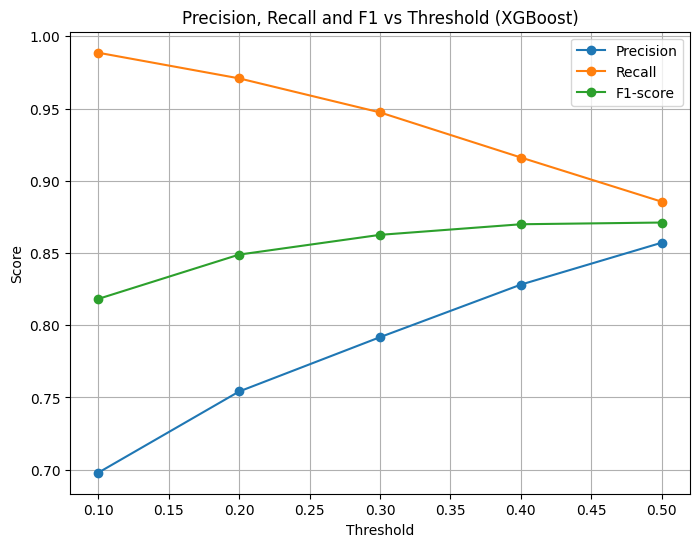

In [54]:
plt.figure(figsize=(8,6))

plt.plot(df_thresh["Threshold"], df_thresh["Precision"], marker='o', label="Precision")
plt.plot(df_thresh["Threshold"], df_thresh["Recall"], marker='o', label="Recall")
plt.plot(df_thresh["Threshold"], df_thresh["F1"], marker='o', label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold (XGBoost)")
plt.legend()
plt.grid()

plt.show()

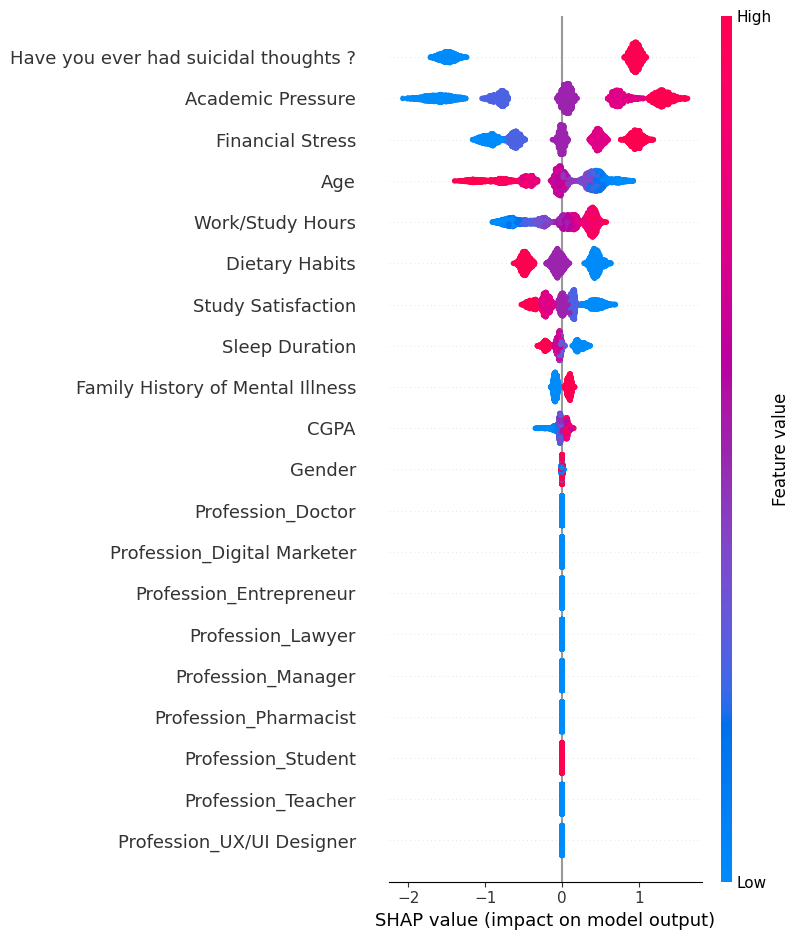

In [55]:
import shap

# create explainer

explainer = shap.TreeExplainer(xgb_model)

# calculate SHAP values
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

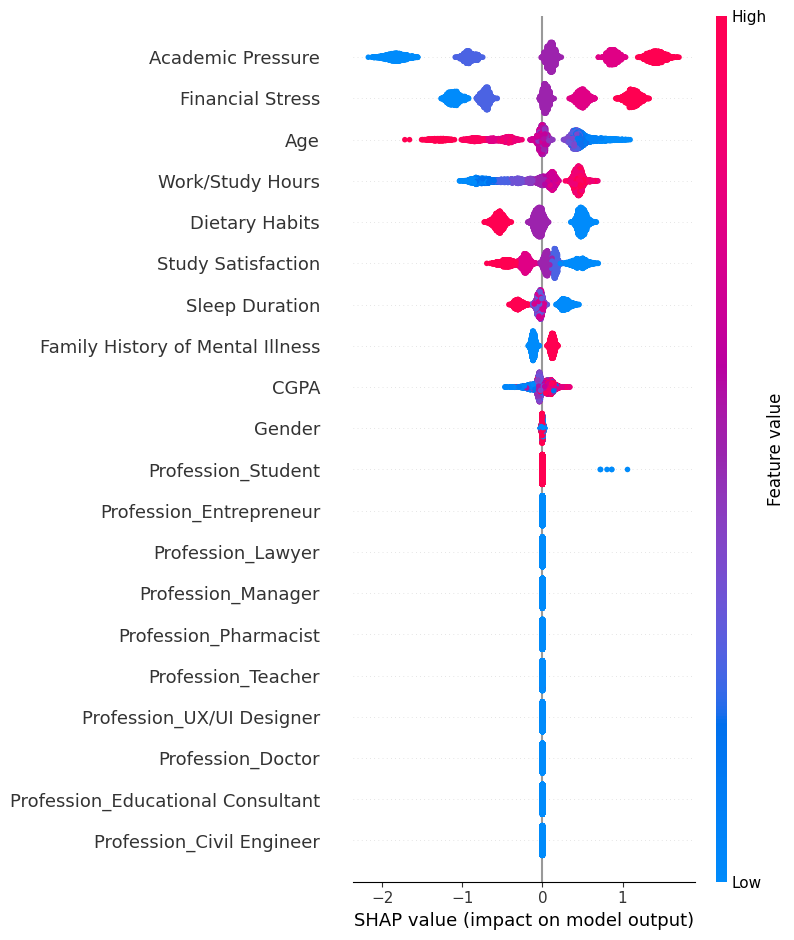

In [56]:
# Create SHAP explainer for XGBoost without suicidal thoughts
explainer_ns = shap.TreeExplainer(xgb_model_ns)

# calculate SHAP values on the test set without suicidal thoughts
shap_values_ns = explainer_ns(X_test_ns)

# Summary plot
shap.summary_plot(shap_values_ns, X_test_ns)

In [ ]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(xgb_model_ns, "xgb_model_ns.pkl")
best_threshold = 0.4
joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']